In [ ]:
#Comensation file

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may

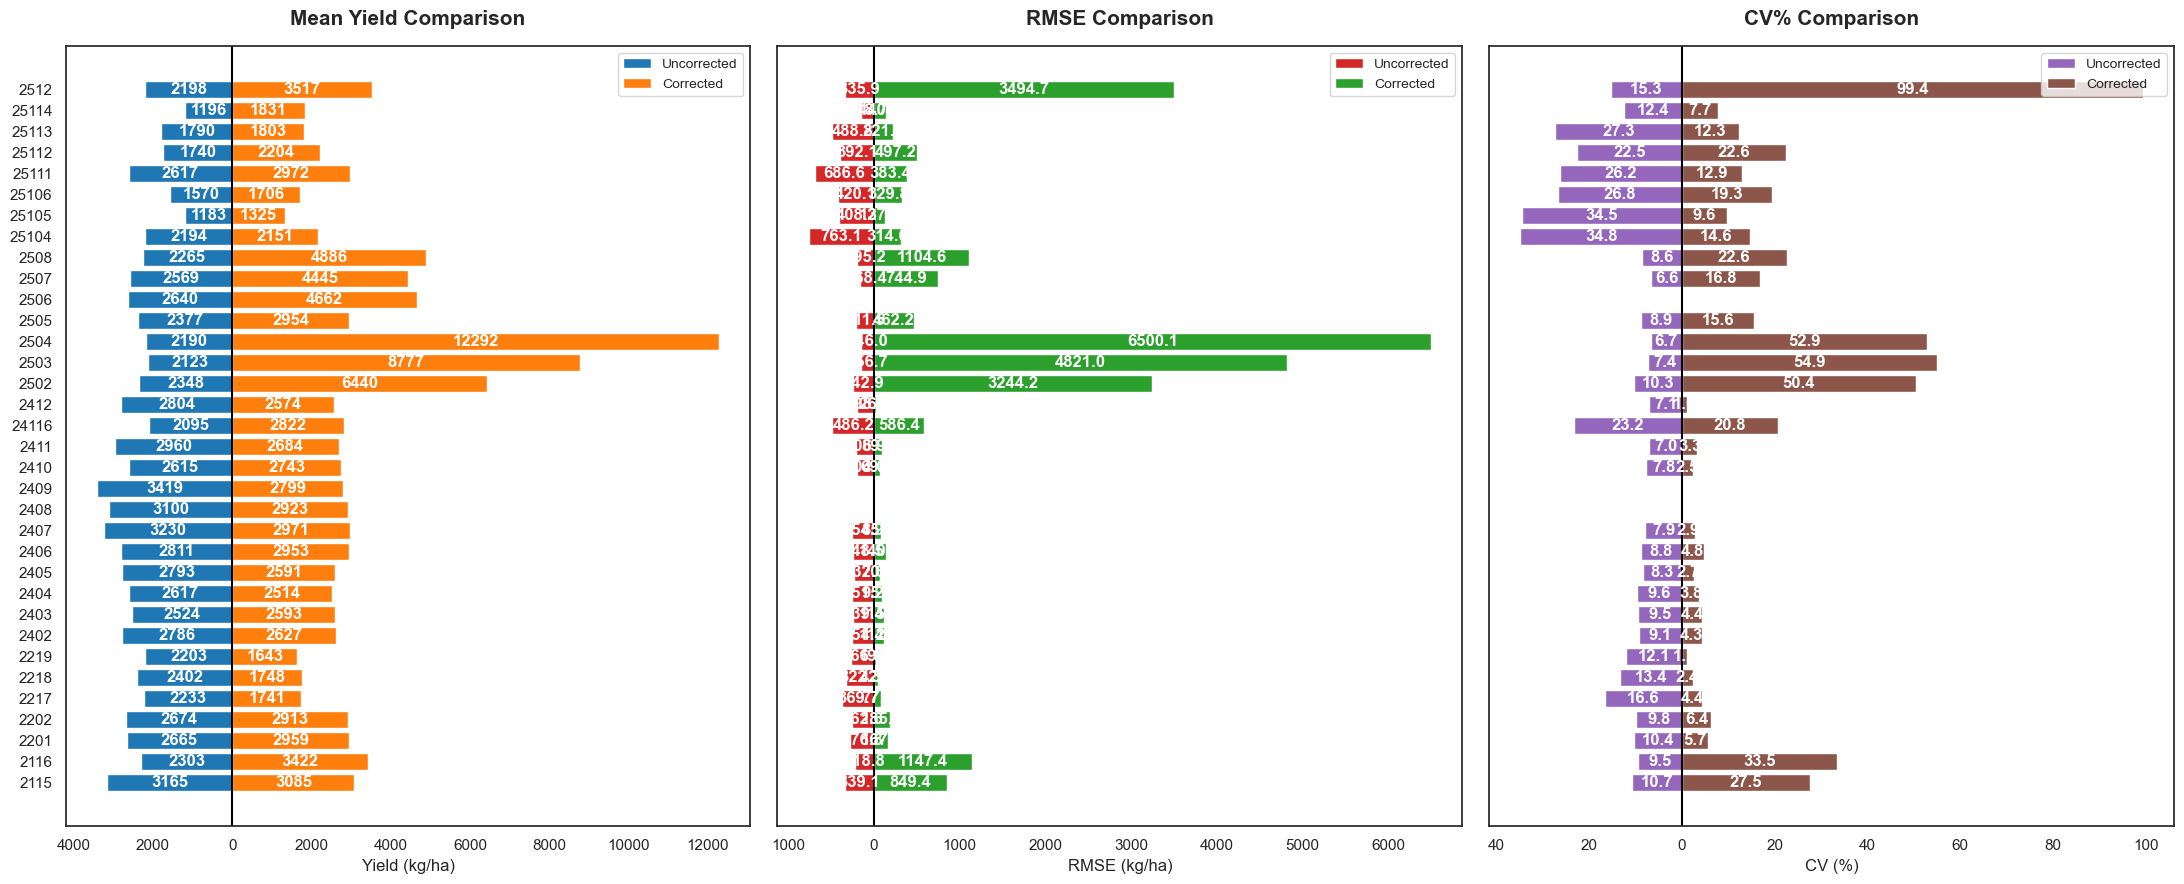

Analysis complete. Metrics for 34 trials calculated and plotted.


In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FixedLocator

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---

#---------------------------Compensation method-------------------------
#file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_compensation_yield.xlsx"

#---------------------------non linear method-------------------------
#file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_NewYield.xlsx"



#---------------------------Spatial correction-------------------------
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_with_spatial_residual_adjusted_yield.xlsx"

df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip()
df = df.rename(columns={'Corrected_Yield': 'CorrectedYield', 'Uncorrected_Yield': 'UncorrectedYield'})

# Ensure categorical types for factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df.columns:
        df[col] = df[col].astype(str)

def calculate_metrics(data, trait):
    """Calculates Mean, RMSE, and CV using consistent mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: 
        return np.nan, np.nan, np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            # Mixed Linear Model
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            # Fallback to OLS
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        mean_val = analysis_data[trait].mean()
        rmse_val = np.sqrt(mse)
        cv_val = (rmse_val / mean_val) * 100
        return mean_val, rmse_val, cv_val
    except:
        return np.nan, np.nan, np.nan

# --- CALCULATION LOOP ---
results_list = []
for exp_name, exp_data in df.groupby('Experiment Name'):
    # Calculate for Uncorrected
    u_mean, u_rmse, u_cv = calculate_metrics(exp_data, 'UncorrectedYield')
    # Calculate for Corrected
    c_mean, c_rmse, c_cv = calculate_metrics(exp_data, 'CorrectedYield')
    
    # Only append if we have valid results for both
    if np.isfinite([u_mean, c_mean]).all():
        results_list.append({
            'Trial': exp_name,
            'Uncorrected_Mean': u_mean, 'Corrected_Mean': c_mean,
            'Uncorrected_RMSE': u_rmse, 'Corrected_RMSE': c_rmse,
            'Uncorrected_CV': u_cv, 'Corrected_CV': c_cv
        })

results_df = pd.DataFrame(results_list)

# --- VISUALIZATION (TRIPLE PANEL TORNADO) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 9), sharey=True)
sns.set_theme(style="white")

def plot_tornado(ax, left_data, right_data, left_label, right_label, title, unit, color_l, color_r, is_int=False):
    ax.barh(results_df['Trial'], -left_data, color=color_l, label=left_label)
    ax.barh(results_df['Trial'], right_data, color=color_r, label=right_label)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=15, pad=15, fontweight='bold')
    ax.set_xlabel(unit, fontsize=12)
    
    # Add labels inside bars
    for i, (l, r) in enumerate(zip(left_data, right_data)):
        fmt = ".0f" if is_int else ".1f"
        ax.text(-l/2, i, f"{l:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
        ax.text(r/2, i, f"{r:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
    
    # Fix X-axis ticks to show absolute values
    ticks = ax.get_xticks()
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{abs(x):.0f}" for x in ticks])
    ax.legend(loc='upper right', fontsize=10)

# Panel 1: Mean
plot_tornado(ax1, results_df['Uncorrected_Mean'], results_df['Corrected_Mean'], 
             'Uncorrected', 'Corrected', 'Mean Yield Comparison', 'Yield (kg/ha)', 
             '#1f77b4', '#ff7f0e', is_int=True)

# Panel 2: RMSE
plot_tornado(ax2, results_df['Uncorrected_RMSE'], results_df['Corrected_RMSE'], 
             'Uncorrected', 'Corrected', 'RMSE Comparison', 'RMSE (kg/ha)', 
             '#d62728', '#2ca02c')

# Panel 3: CV%
plot_tornado(ax3, results_df['Uncorrected_CV'], results_df['Corrected_CV'], 
             'Uncorrected', 'Corrected', 'CV% Comparison', 'CV (%)', 
             '#9467bd', '#8c564b')

plt.tight_layout()
plt.savefig('Triple_Panel_Consistent_Tornado.png', dpi=300)
plt.show()

print(f"Analysis complete. Metrics for {len(results_df)} trials calculated and plotted.")